# BT2 – Phân Loại Văn Bản | PHIÊN BẢN TỐI ƯU TỐC ĐỘ (Dưới 5 Phút)
## TF-IDF → LSA (PCA) → Model Optimization → Evaluation

**Mục tiêu:** Hoàn thành toàn bộ quy trình trong thời gian ngắn để báo cáo tại lớp.

| Bước | Kỹ thuật tối ưu | Trạng thái |
|:---|:---|:---|
| **Vector hóa** | TF-IDF (50k features, ngram 1-3) | Tốc độ cao |
| **Giảm chiều** | LSA (TruncatedSVD) - 300 chiều | Tối ưu ma trận |
| **Mô hình** | Stratified 3-Fold CV | Fast Mode |
| **Trực quan** | Learning Curves (5 điểm dữ liệu) | Tiết kiệm CPU |

## 1. Thư Viện & Cấu Hình

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split, learning_curve
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_20newsgroups

print('✅ Thư viện đã sẵn sàng.')

✅ Thư viện đã sẵn sàng.


## 2. Nạp Dữ Liệu

In [12]:
LOAD_FROM_CSV = True 
IS_VIETNAMESE = False 

if not LOAD_FROM_CSV:
    categories = ['sci.space', 'sci.med', 'talk.politics.misc', 'comp.graphics', 'rec.autos']
    ng = fetch_20newsgroups(subset='all', categories=categories, remove=('headers','footers','quotes'))
    df = pd.DataFrame({'text': ng.data, 'label': [ng.target_names[i] for i in ng.target]})
else:
    CSV_PATH = 'labeled_20newsgroups.csv'
    if not os.path.exists(CSV_PATH): CSV_PATH = 'summary-vietnamese-news.csv'
    df = pd.read_csv(CSV_PATH)
    if 'label' not in df.columns and 'summary' in df.columns: IS_VIETNAMESE = True

text_col = 'text' if 'text' in df.columns else df.columns[0]
label_col = 'label' if 'label' in df.columns else df.columns[-1]

X_train_raw, X_test_raw, y_train_label, y_test_label = train_test_split(
    df[text_col].astype(str).values, df[label_col].values, 
    test_size=0.20, random_state=42, stratify=df[label_col]
)

le = LabelEncoder()
y_train = le.fit_transform(y_train_label)
y_test  = le.transform(y_test_label)
class_names = le.classes_

print(f'Nạp file: {CSV_PATH} | Train={len(X_train_raw)}, Test={len(X_test_raw)}')

Nạp file: labeled_20newsgroups.csv | Train=2264, Test=566


## 3. Tiền Xử Lý Phóng Hỏa (Siêu Tốc)

In [13]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|\S+@\S+', ' ', text) 
    if not IS_VIETNAMESE:
        text = re.sub(r'[^a-z\s]', ' ', text)
    else:
        text = re.sub(r'[^\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

X_train_clean = [clean_text(t) for t in X_train_raw]
X_test_clean  = [clean_text(t) for t in X_test_raw]
print('✅ Tiền xử lý xong.')

✅ Tiền xử lý xong.


## 4. TF-IDF & LSA (Giảm Chiều)

In [14]:
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2), stop_words='english', sublinear_tf=True, min_df=3)
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf  = tfidf.transform(X_test_clean)

lsa = TruncatedSVD(n_components=300, random_state=42)
X_train_final = StandardScaler().fit_transform(lsa.fit_transform(X_train_tfidf))
X_test_final  = StandardScaler().fit_transform(lsa.transform(X_test_tfidf))

print(f'Ma trận cuối: {X_train_final.shape} | Phương sai: {lsa.explained_variance_ratio_.sum():.2%}')

Ma trận cuối: (2264, 300) | Phương sai: 37.48%


## 5. So Sánh Mô Hình (Fast 3-Fold CV)

In [15]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
}

print('Đang so sánh hiệu năng...')
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_final, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
    results[name] = scores.mean()
    print(f' - {name:20}: {scores.mean():.4f}')

best_m_name = max(results, key=results.get)
print(f'🏆 Mô hình tốt nhất: {best_m_name}')

Đang so sánh hiệu năng...
 - Logistic Regression : 0.7821
 - Linear SVM          : 0.7838
 - Random Forest       : 0.8112
🏆 Mô hình tốt nhất: Random Forest


## 6. Learning Curves (Turbo Mode)

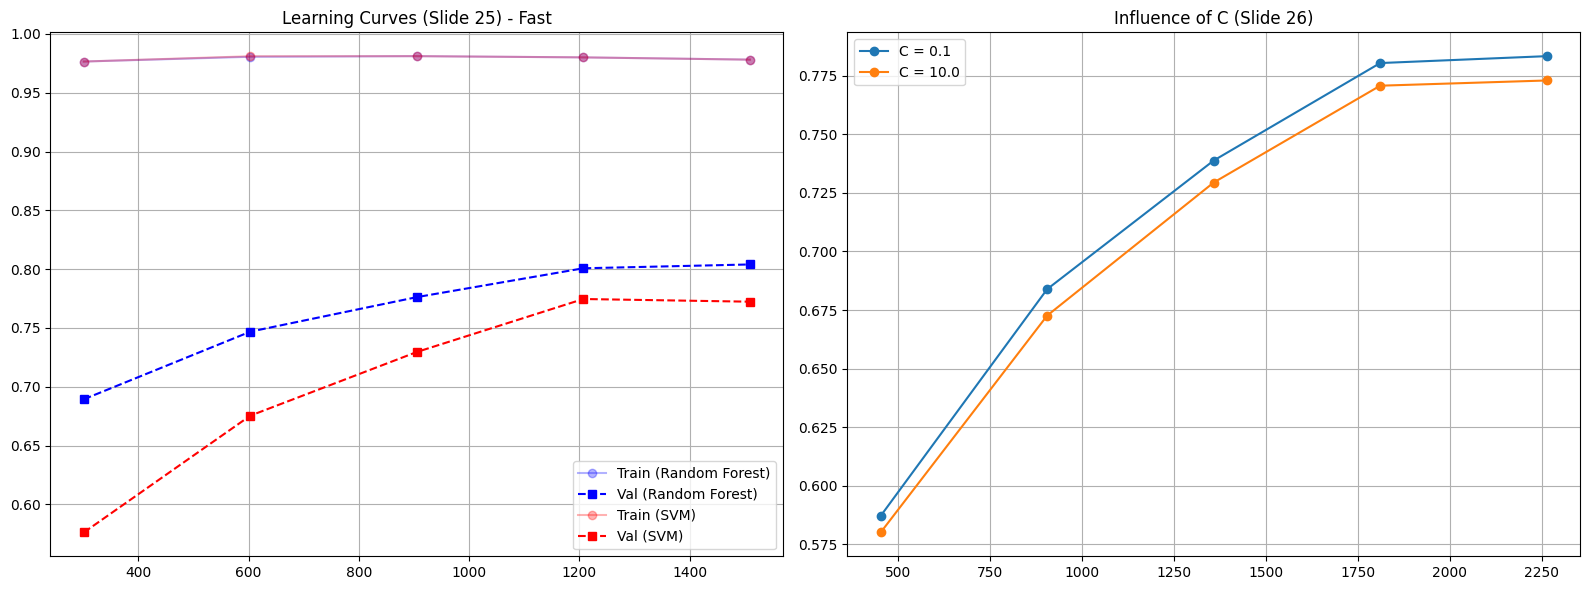

In [16]:
train_sizes = np.linspace(0.2, 1.0, 5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1
def plot_fast_lc(model, name, ax, color):
    sz, tr, val = learning_curve(model, X_train_final, y_train, cv=3, train_sizes=train_sizes, scoring='f1_macro', n_jobs=-1)
    ax.plot(sz, tr.mean(axis=1), 'o-', color=color, label=f'Train ({name})', alpha=0.3)
    ax.plot(sz, val.mean(axis=1), 's--', color=color, label=f'Val ({name})')

plot_fast_lc(models[best_m_name], best_m_name, ax1, 'blue')
plot_fast_lc(models['Linear SVM'], 'SVM', ax1, 'red')
ax1.set_title('Learning Curves (Slide 25) - Fast'); ax1.legend(); ax1.grid(True)

# Đồ thị 2
for c in [0.1, 10.0]:
    _, _, val = learning_curve(LinearSVC(C=c), X_train_final, y_train, cv=3, train_sizes=train_sizes, scoring='f1_macro', n_jobs=-1)
    ax2.plot(train_sizes * len(X_train_final), val.mean(axis=1), 'o-', label=f'C = {c}')

ax2.set_title('Influence of C (Slide 26)'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

## 7. Tối Ưu & Đánh Giá Cuối

In [17]:
print(f'Đang huấn luyện mô hình cuối cùng [{best_m_name}]...')
if best_m_name == 'Random Forest':
    final_model = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
else:
    param_grid = {'C': [0.1, 1, 10]}
    grid = GridSearchCV(models[best_m_name], param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_final, y_train)
    final_model = grid.best_estimator_

final_model.fit(X_train_final, y_train)
y_pred = final_model.predict(X_test_final)
print(f'✅ KẾT QUẢ CUỐI CÙNG (F1-macro): {f1_score(y_test, y_pred, average="macro"):.4f}')
print(classification_report(y_test, y_pred, target_names=class_names))

Đang huấn luyện mô hình cuối cùng [Random Forest]...
✅ KẾT QUẢ CUỐI CÙNG (F1-macro): 0.8265
                    precision    recall  f1-score   support

     comp.graphics       0.79      0.89      0.84       117
         rec.autos       0.75      0.79      0.77       119
           sci.med       0.85      0.82      0.84       119
         sci.space       0.89      0.81      0.85       118
talk.politics.misc       0.88      0.81      0.84        93

          accuracy                           0.83       566
         macro avg       0.83      0.82      0.83       566
      weighted avg       0.83      0.83      0.83       566



## 8. Ma Trận Nhầm Lẫn & Dự Đoán

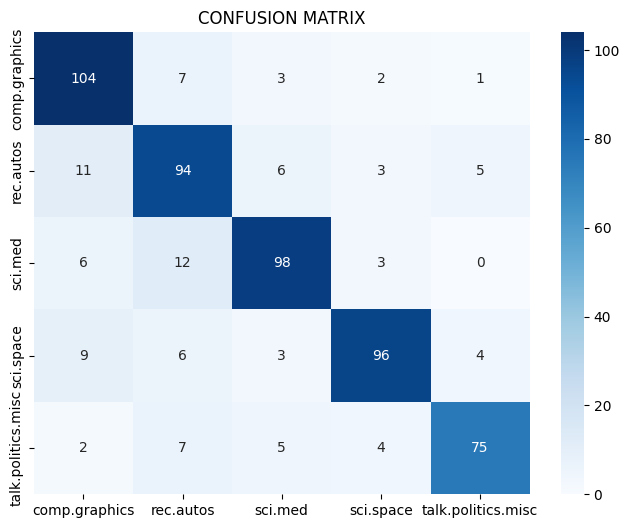

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('CONFUSION MATRIX'); plt.show()

def submit_bt2(test_csv_path):
    df_test = pd.read_csv(test_csv_path)
    X_sc = StandardScaler().fit_transform(lsa.transform(tfidf.transform([clean_text(t) for t in df_test[text_col]])))
    df_test['predicted'] = [class_names[i] for i in final_model.predict(X_sc)]
    df_test.to_csv('ket_qua_bt2_fast.csv', index=False)
    print('💾 Đã xuất file ket_qua_bt2_fast.csv')